Assignment topic - Supervised Learning for Sequential Data: RNN+LSTM

Date - 7.04.2026

name - Riddhi

Roll number - CS23B2024



In [ ]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

# CONFIG
MAX_VOCAB_SIZE = 20000
MAX_LEN = 50
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
BATCH_SIZE = 64
EPOCHS = 5
LR = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# LOAD DATA
train_df = pd.read_parquet("sst2_train.parquet")
val_df = pd.read_parquet("sst2_valid.parquet")

# Split 5000 for test
train_df, test_df = train_test_split(train_df, test_size=5000, random_state=42)

# PREPROCESSING FUNCTIONS
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

def tokenize(text):
    return text.split()

train_df["sentence"] = train_df["sentence"].apply(clean_text)
val_df["sentence"] = val_df["sentence"].apply(clean_text)
test_df["sentence"] = test_df["sentence"].apply(clean_text)

# Build vocab
counter = Counter()
for sent in train_df["sentence"]:
    counter.update(tokenize(sent))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, freq in counter.most_common(MAX_VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

def encode(text):
    tokens = tokenize(text)
    ids = [vocab.get(t, vocab["<UNK>"]) for t in tokens]
    if len(ids) < MAX_LEN:
        ids += [vocab["<PAD>"]] * (MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]
    return ids

# Encode datasets
def process_df(df):
    X = np.array([encode(s) for s in df["sentence"]])
    y = np.array(df["label"])
    return X, y

X_train, y_train = process_df(train_df)
X_val, y_val = process_df(val_df)
X_test, y_test = process_df(test_df)

# DATASET CLASS
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TextDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TextDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(TextDataset(X_test, y_test), batch_size=BATCH_SIZE)

# MODELS
class RNNModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBEDDING_DIM, padding_idx=0)
        self.rnn = nn.RNN(EMBEDDING_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.rnn(x)
        out = self.fc(hidden.squeeze(0))
        return torch.sigmoid(out).squeeze()

class LSTMModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBEDDING_DIM, padding_idx=0)
        self.lstm = nn.LSTM(EMBEDDING_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden.squeeze(0))
        return torch.sigmoid(out).squeeze()

# TRAIN & EVAL
def train_model(model, train_loader, val_loader):
    model.to(DEVICE)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_accs = []
    val_accs = []

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_acc = evaluate(model, train_loader)
        val_acc = evaluate(model, val_loader)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return train_accs, val_accs
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            outputs = model(X)
            preds = (outputs > 0.5).float()

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

print("Training RNN")
rnn_train_accs, rnn_val_accs = train_model(rnn_model, train_loader, val_loader)
rnn_test_acc = evaluate(rnn_model, test_loader)

print("Training LSTM")
lstm_train_accs, lstm_val_accs = train_model(lstm_model, train_loader, val_loader)
lstm_test_acc = evaluate(lstm_model, test_loader)

# COMPARISON
print("\n===== RESULTS =====")
print(f"RNN Test Accuracy  : {rnn_test_acc:.4f}")
print(f"LSTM Test Accuracy : {lstm_test_acc:.4f}")

if lstm_test_acc > rnn_test_acc:
    print("LSTM performs better (captures long-term dependencies)")
else:
    print("RNN performs similar or better (simpler model)")

Training RNN
Epoch 1, Loss: 670.8461, Train Acc: 0.5521, Val Acc: 0.5310
Epoch 2, Loss: 669.4866, Train Acc: 0.5528, Val Acc: 0.5287
Epoch 3, Loss: 669.8152, Train Acc: 0.5411, Val Acc: 0.5092
Epoch 4, Loss: 669.3978, Train Acc: 0.5497, Val Acc: 0.5092
Epoch 5, Loss: 671.1674, Train Acc: 0.5571, Val Acc: 0.5092
Training LSTM
Epoch 1, Loss: 408.0660, Train Acc: 0.8491, Val Acc: 0.7718
Epoch 2, Loss: 340.2171, Train Acc: 0.8803, Val Acc: 0.7890
Epoch 3, Loss: 299.8407, Train Acc: 0.8925, Val Acc: 0.7913
Epoch 4, Loss: 277.4996, Train Acc: 0.9108, Val Acc: 0.7993
Epoch 5, Loss: 242.3343, Train Acc: 0.9221, Val Acc: 0.8142

===== RESULTS =====
RNN Test Accuracy  : 0.5666
LSTM Test Accuracy : 0.8866
LSTM performs better (captures long-term dependencies)


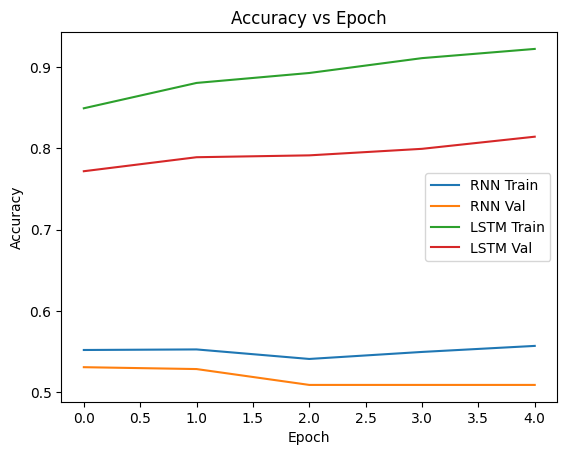

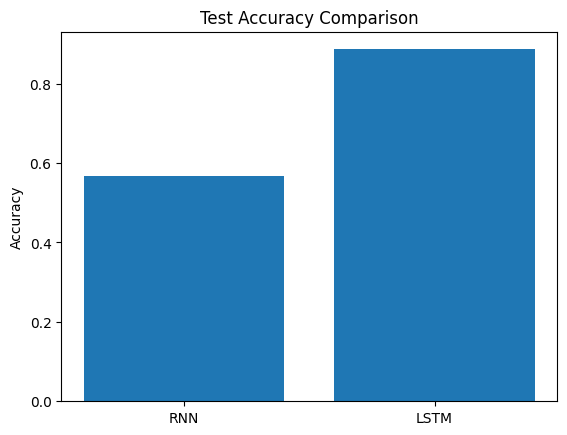

In [ ]:
import matplotlib.pyplot as plt

#ACCURACY vs EPOCH
plt.figure()
plt.plot(rnn_train_accs, label="RNN Train")
plt.plot(rnn_val_accs, label="RNN Val")
plt.plot(lstm_train_accs, label="LSTM Train")
plt.plot(lstm_val_accs, label="LSTM Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

#BAR CHART COMPARISON
plt.figure()
plt.bar(["RNN", "LSTM"], [rnn_test_acc, lstm_test_acc])
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()